### satellite_fetcher.py

##### satellite_fetcher.py

#### **DAY 4: THE SATELLITE EYE** - Connecting PostGIS to Earth Engine

##### **BACKGROUND:**
- We have 12+ farm polygons in PostGIS from Day3.
- They are shapes. They know nothing about history.
- Today we give them  memory. We pull 5 years of Sentinel-1 SAR backscatter data from Google Eath Engine for each farm.

##### **WHAT IS BACKSCATTER?**
- A SAR satellite sends radar pulses to Earth and measures what bounces back.
- Dry land bounces back moderatly.
- Water bounces almost nothing back (like a mirror deflecting light).
- This difference - measured in decibels (dB) - IS the flood signal.

##### **WHY GOOGLE EARTH ENGINE?**
- Sentinel-1 has been photographing Dhaldabri since 2015. Those images are stored on Google's servers.
- We don't download them (gigabytes). We send our farm polygons UP to GEE and get back only the numbers we need.
- This is "cloud-native" geospatial processing.


 


In [2]:
import ee
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import create_engine, text
# from config import Config
import warnings
warnings.filterwarnings('ignore')


In [12]:
# -- STEP 1: AUTHENTICATE WITH GOOGLE EARTH ENGINE ----
#==================================================================================== 
# BACKGROUND: 
#    ee.Initialize() 
#         - connects your Python script to Google's satellite archive
#         - Without this, we can't access any satellite data.
#    Run 'earthengine authenticate' in terminal first to link your Google account.
#====================================================================================
# 1. Authenticate FIRST
ee.Authenticate()

# 2. Initialize SECOND with your project ID
ee.Initialize(project='aravalli-shield-2025')

print("|-- [LOG]: Google Earth Engine connection established.")


|-- [LOG]: Google Earth Engine connection established.


In [13]:
# -- STEP 2: MAKE CONNECTION WITH THE DATABASE ----
#==================================================================================== 
import os
import sys
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# 1. Path Navigation: Go 2 levels up to root, then 1 down to day03
root_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
day03_path = os.path.join(root_path, 'day03-geopandas+postgis')

# 2. Add Day 03 to sys.path so we can import 'Config'
if day03_path not in sys.path:
    sys.path.append(day03_path)

# 3. Load the .env located in the Day 03 folder
dotenv_path = os.path.join(day03_path, '.env')
load_dotenv(dotenv_path)

# 4. Import the Config class
from config import Config

# 5. Create the Engine using the URL from Config
engine = create_engine(Config.DB_URL)

print(f"✅ [SUCCESS]: Connected to PostGIS at {Config.DB_HOST}")


✅ [SUCCESS]: Connected to PostGIS at localhost


In [14]:
# -- STEP 3: GET THE ORDER FROM DATABASE (PostGIS) ----
#==================================================================================== 
def load_farms_from_postgis():
    """
    BACKGROUND:
        - We fetch farm boundaries from PostGIS (Our Spatial Vault from Day3) as GeoJSON.

        - ST_AsGeoJSON() is a PostGIS function that  converts our stored GEOMETRY type into a JSON string that GEE can read.
        
    WHY NOT USE THE PARQUET FILE DIRECTLY?
        - The PostGIS database is the single source of truth.
        - The parquet file was a staging file. Always read from the authoritative source. 
    """
    print("\n|-- [LOG]: Loading farm boundaries from PostGIS...")

    query = """
    
        SELECT
            farm_id,
            farmer_name,
            area_hectares,
            ST_AsGeoJSON(geom_inner) as geometry_json
         FROM farm_boundaries
         ORDER BY farm_id;
    
    """ 
    with engine.connect() as conn:
        result = conn.execute(text(query))
        farms = [dict(row._mapping) for row in result]

    print(f"|--[LOG]: Loaded {len(farms)} farms from the vault.")

    return farms


# # Execute the function
# farms_data = load_farms_from_postgis()

In [15]:
# farms_data

In [16]:
# -- STEP 4: HANDOVER THE ORDERS TO GOOGLE EARTH ENGINE ----
#==================================================================================== 
def farm_to_ee_geometry(geometry_json_str):
    """
    BACKGROUND:
        - GEE uses its own Geometry objects - not Python dicts or Shapely shapes.
        - We parse the GeoJSON string from  PostGIS and hand it to GEE.

    NOTE:
        - We use geom_inner (the 3m-shrunk boundary from Day3).
        - This ensures SAR pixels sample 100% crop, not road edges.
        - This is Basis Risk reduction from Day3 paying dividends now.
         
    """
    geojson = json.loads(geometry_json_str)
    return ee.Geometry(geojson)


 

        

In [17]:
# -- STEP 5: NOW GOOGLE EARTH ENGINE (GEE) WILL TALK TO SERVER FOR REQUIRED DATA (Sentinel-1 SAR)----
#===================================================================================================== 
def fetch_sar_timeseries(farm_id, ee_geometry, start_year=2019, end_year=2026):
    """
    BACKGROUND:
        - This function asks GEE to:
                    - 1) Find all Sentinel-1 SAR images over this farm polygon.
                    - 2) Filter to only monsoon season (June-October each year)
                    - 3) For each image, calculate the average VV backscatter inside the farm boundary.
                    - 4) Return a list of (date, dB_value) pairs

    WHAT IS VV POLARIZATION?
        - SAR sends radio waves in different orientations.
        - VV = Vertical send, Vertical receive.
        - VV is best for detecting surface water - flooded fields
        - show a dramatic dip in VV BACKSCATTER.

        - VH polarization is better for crop structure detection.
        - We use VV for flood detection.

    WHAT IS reduceRegion()?
        - Instead of getting backscatter for every pixel indise the farm (clould be thousands of numbers),
        - we calculate the MEAN backsatter across all pixels.
        - One number per image per farm. Clean. Efficient.
    """

    # Define the Sentinel-1 SAR collection
    # BACKGROUND: 'COPERNICUS/S1_GRD' is the GEE collection name
    # GRD = Ground Range Detected (pre-processed, ready to use)
    # IW = Interferometric Wide swath mode (standard for India)
    collection = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(ee_geometry)
        .filterDate(f"{start_year}-01-01", f"{end_year}-04-06")
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .select('VV')
    )
    def extract_mean(image):
        """
        BACKGROUND:
            - For each satellite pass, calculate the mean VV backscatter inside the farm boundary.
            - reduceReggion with ee.Reducer.mean() averages all pixels.
            - scale=10 means: use 10-metre pixel resolution (Sentinel-1 native).
        """
        mean_dict = image.reduceRegion(
            reducer = ee.Reducer.mean(),
            geometry = ee_geometry,
            scale = 10,
            maxPixels=1e9
        )
        return image.set({
             'date': image.date().format('YYYY-MM-dd'),
             'vv_mean': mean_dict.get('VV')
         })

    # Apply extraction to every image in the collection
    with_stats = collection.map(extract_mean)

    # Pull results from GEE servers to local Python
    # BACKGROUND:
    #    - GEE is lazy - it only runs computations when you call .getInfo()
    #    - This is the network request
    data = with_stats.reduceColumns(
        ee.Reducer.toList(2),
        ['date', 'vv_mean']
    ).getInfo()

    records = data.get('list', [])
    if not records:
        print(f"|--[WARN]: No SAR data found for {farm_id} ")
        return pd.DataFrame()

    df = pd.DataFrame(records, columns=['date', 'vv_db'])
    df['date'] = pd.to_datetime(df['date'])
    df['farm_id'] = farm_id

    df = df.dropna(subset=['vv_db'])
    df = df.sort_values('date')

    return df


In [18]:
# -- STEP 6: NOW WE HAVE OUR REQUIRED DATA FOR FARTHER ANALYSIS ----
#==================================================================================== 
def detect_flood_events(df, threshold_db = -18.0):
    """
    BACKGROUND:
        - This is the simplest possible flood detector
    
    THE THRESHOLD METHOD:
        - We know from SAR physics that:
                            - Open water has backscatter below approximately -18 dB in VV polarisation.
        - If the mean VV backscatter across a farm drops below -18 dB,
          the farm is likely underwater.
        - This is called a "threshold-based" flood detector.
        - It's not perfect (it's our v1), but it works.

        - In Day 7+ we will train a PyTorch U-Net to detect floods more accurately - 
          but that model will be validated against these threshold results.
        - We can't improve what we haven't measured first.

    WHAT IS BASIS RISK HERE?
        - If the threshold is too high (-15 dB), we flag dry fields as flooded - false positive.
          Farmer gets paid when they shouldn't. Insurer loses money.
        - If the threshold is too low (-22 dB), we miss real floods - false negative.
        - Farmer flooded but gets no payout.
          Farmer loses ₹20,000.

        - (-18 dB) is the literature-accepted starting point for West Bengal C-band SAR flood detection.
        - We will calibrate this with Dhaldabri ground trouth data.
    """
    df['is_flooded'] = df['vv_db'] < threshold_db
    flood_events = df[df['is_flooded']]

    return df, flood_events


In [19]:
# -- STEP 7: PLOT SAR TIME SERIES  ----
#==================================================================================== 
def plot_sar_history(farm_id, df, flood_events):
    """
    BACKGROUND:
        - Visualise the backscatter time series.

    A healthy farm shows backscatter fluctuating between (-10 and -15) dB across the season 
    as crops grow.

    A flooded farm shows a sharp DIP below -18 dB.

    We are looking for those dips. Each dip is a flood event.
    If a dip corresponds to July/August (monsoon peak), that's our Dhaldabri flood calender building itself.

    WHY IS THIS EXCITING?
        - This graph is the first time satellite data and our farm database are talking to each other.
        - The shapes from Day3 now have history.
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    # Plot full backscatter history
    ax.plot(df['date'], df['vv_db'],
           color='steelblue', linewidth=1.5,
           label='VV Backscatter (dB)', marker='o', markersize=3)

    # Highlight flood events
    if not flood_events.empty:
        ax.scatter(flood_events['date'], flood_events['vv_db'],
                  color='red', zorder=5, s=8,
                  label=f'Flood Detected (< {-18} dB)')

    # Draw threshold line
    ax.axhline(y=-18, color='red', linestyle= '--',
              linewidth=1, alpha=0.7, label='Flood Threshold (-18 dB)')


    # Shade monsoon seasons (June-October each year)
    # BACKGROUND:
    #     - Monsoon is when floods happen.
    # Shading makes it immediately obvious if flood events
    # cluster during monsoon - which they should
    for year in range(df['date'].dt.year.min(),
                     df['date'].dt.year.max() + 1):
        ax.axvspan(pd.Timestamp(f'{year}-06-01'),
                  pd.Timestamp(f'{year}-10-31'),
                  alpha=0.08, color='orange',
                  label='Monsoon Season' if year == df['date'].dt.year.min() else "")

    ax.set_title(f'Sentinel-1 SAR History - {farm_id} (Dhaldabri, West Bengal)',
                fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('VV Backscatter (dB)')
    ax.legend(loc='lower right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

    plt.xticks(rotation=45)
    plt.tight_layout()

    output_path = f'outputs/sar_history_{farm_id}.png'
    plt.savefig(output_path, dpi=150)
    plt.show()

    print(f"|-- [LOG]: Chart saved to {output_path}")
    

 DAY 4: THE SATELLITE EYE - CONNECTING EARTH TO SKY

|-- [LOG]: Loading farm boundaries from PostGIS...
|--[LOG]: Loaded 14 farms from the vault.

--------------------------------------------------
 |-- [PROCESSING]: DHF001 | Farmer_1 | 4.7249 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -18.1 dB to -6.8 dB
|-- [FLOOD]: 1 potential flood events detected:
    -> July 2019: -18.15 dB 


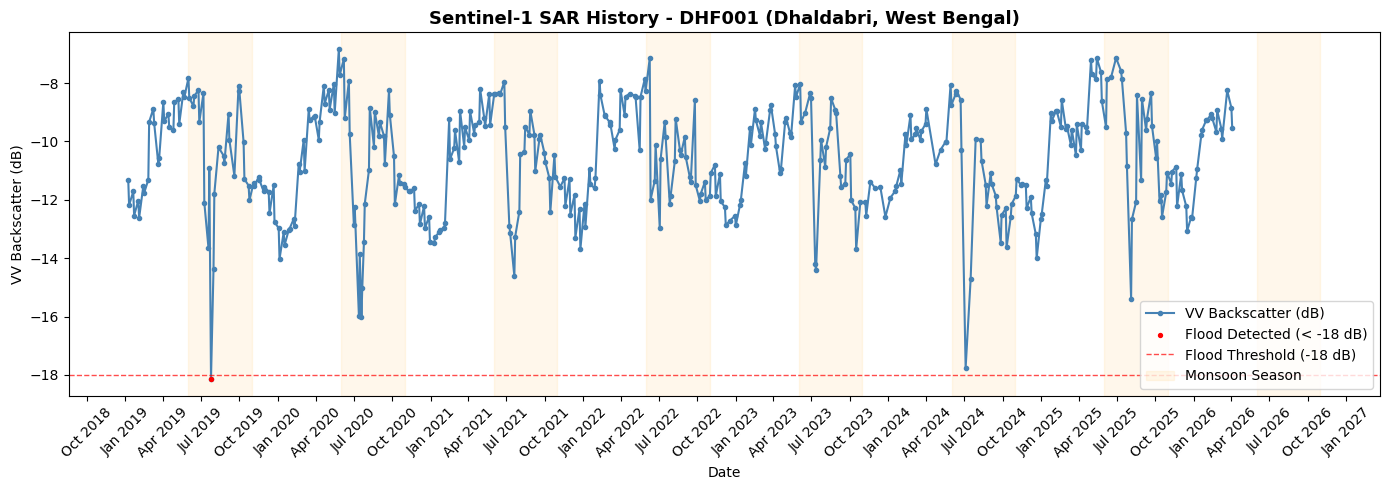

|-- [LOG]: Chart saved to outputs/sar_history_DHF001.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF002 | Farmer_2 | 9.8308 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -18.8 dB to -6.9 dB
|-- [FLOOD]: 1 potential flood events detected:
    -> July 2020: -18.82 dB 


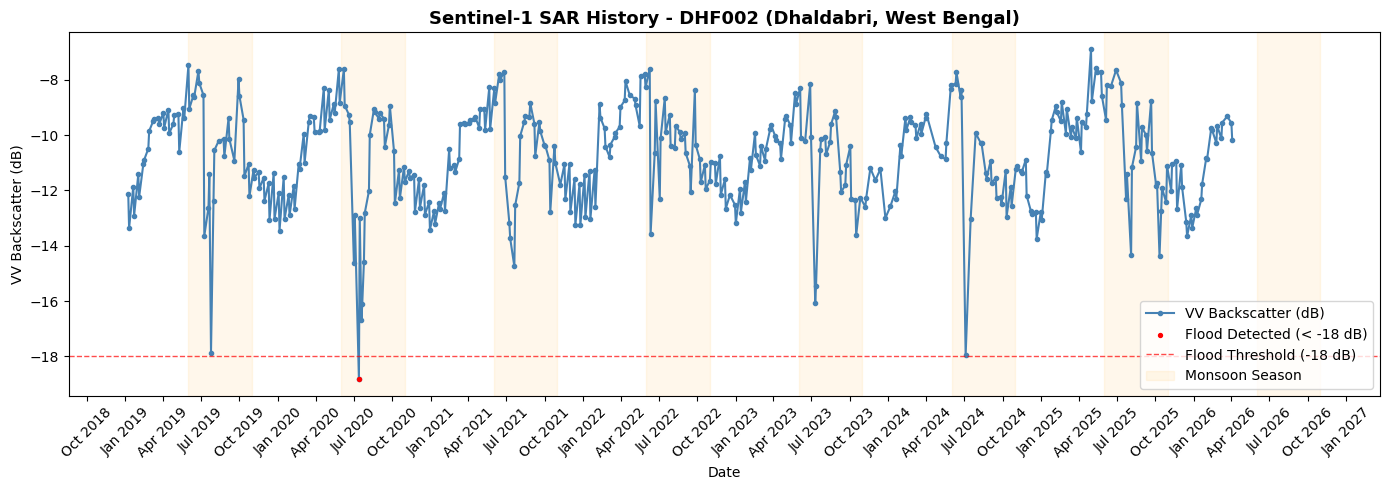

|-- [LOG]: Chart saved to outputs/sar_history_DHF002.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF003 | Farmer_3 | 0.1479 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -15.1 dB to -3.7 dB
 |-- [LOG]: No flood events detected for DHF003


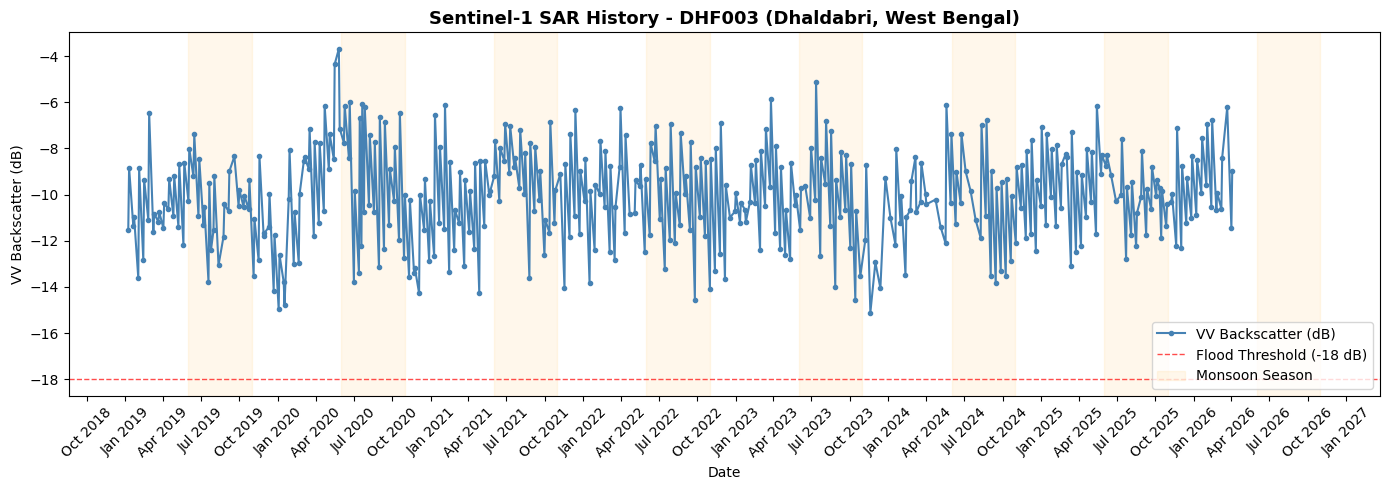

|-- [LOG]: Chart saved to outputs/sar_history_DHF003.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF004 | Farmer_4 | 0.1652 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -15.6 dB to -3.7 dB
 |-- [LOG]: No flood events detected for DHF004


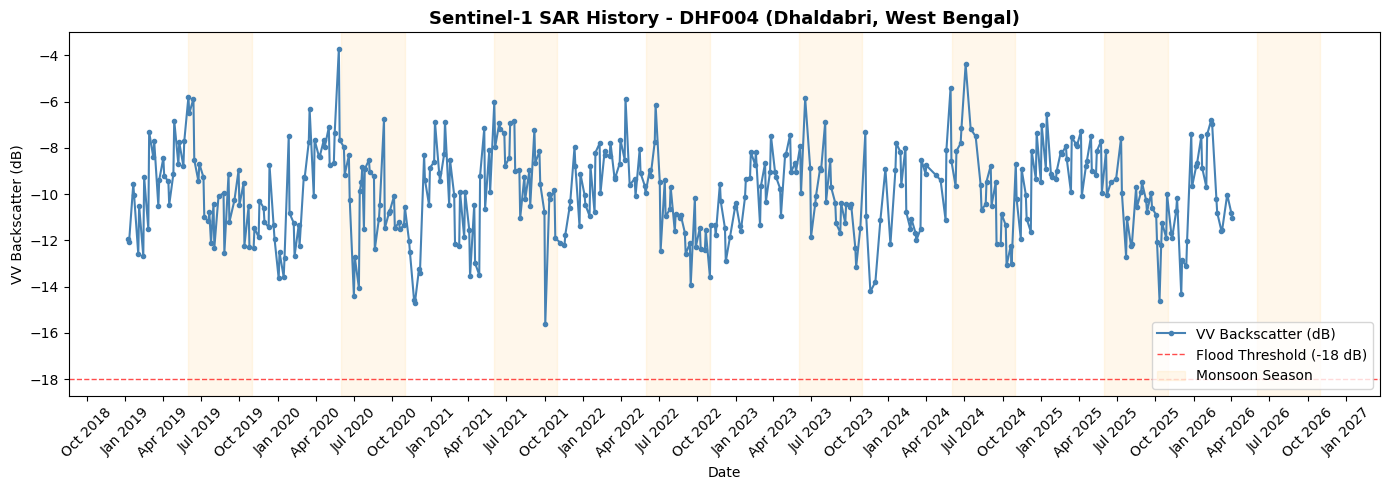

|-- [LOG]: Chart saved to outputs/sar_history_DHF004.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF006 | Farmer_6 | 0.0774 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -15.9 dB to -4.3 dB
 |-- [LOG]: No flood events detected for DHF006


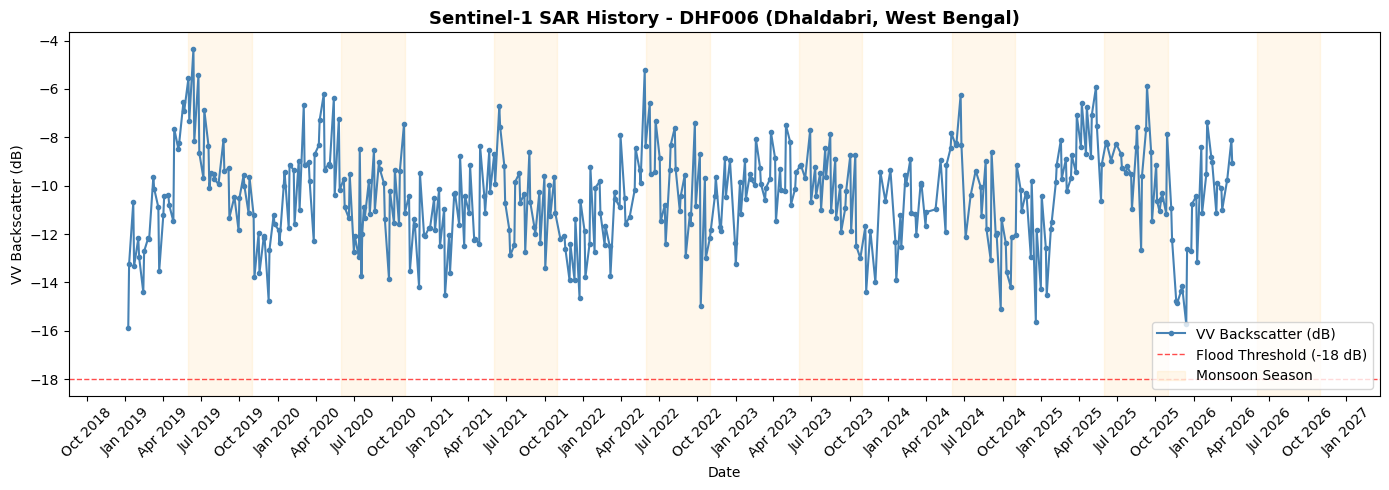

|-- [LOG]: Chart saved to outputs/sar_history_DHF006.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF007 | Farmer_7 | 0.1364 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -15.2 dB to -4.1 dB
 |-- [LOG]: No flood events detected for DHF007


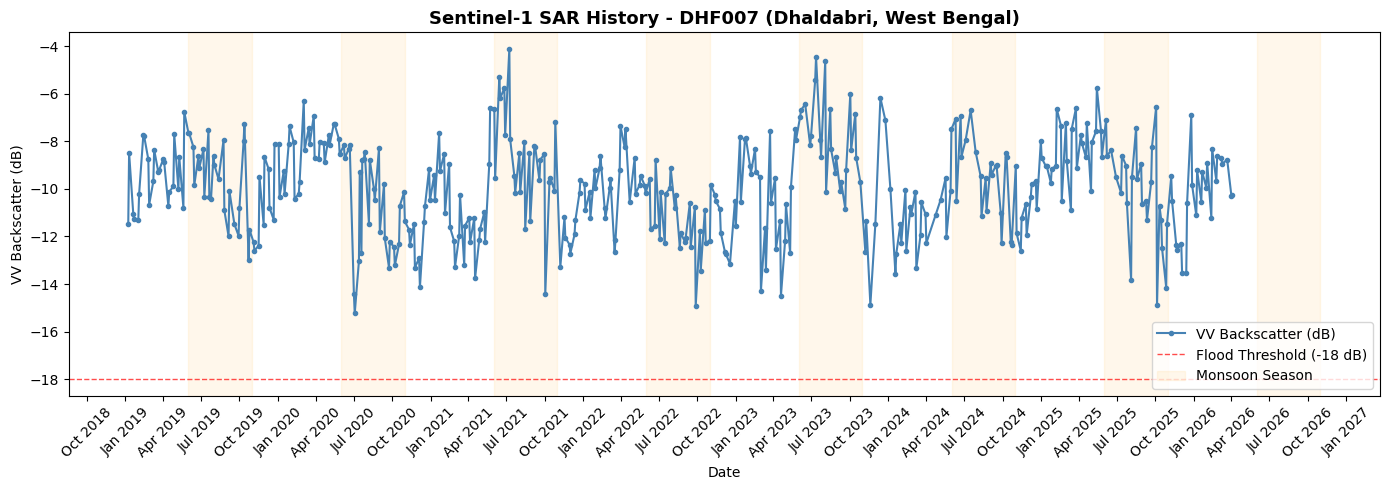

|-- [LOG]: Chart saved to outputs/sar_history_DHF007.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF008 | Farmer_8 | 0.1309 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -16.9 dB to -4.0 dB
 |-- [LOG]: No flood events detected for DHF008


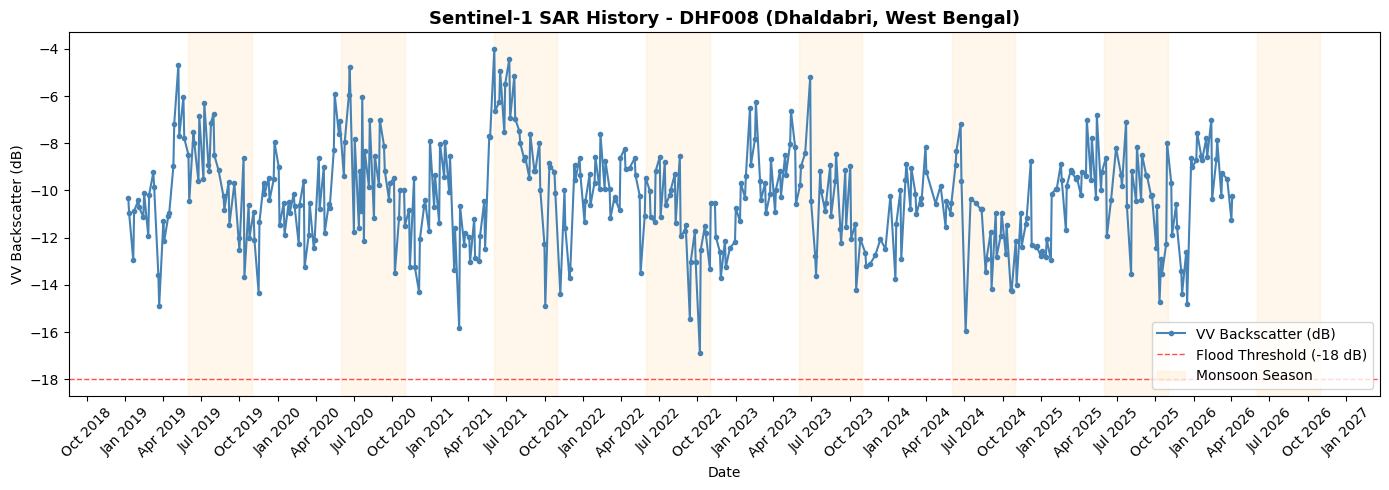

|-- [LOG]: Chart saved to outputs/sar_history_DHF008.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF009 | Farmer_9 | 0.1089 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -17.0 dB to -5.4 dB
 |-- [LOG]: No flood events detected for DHF009


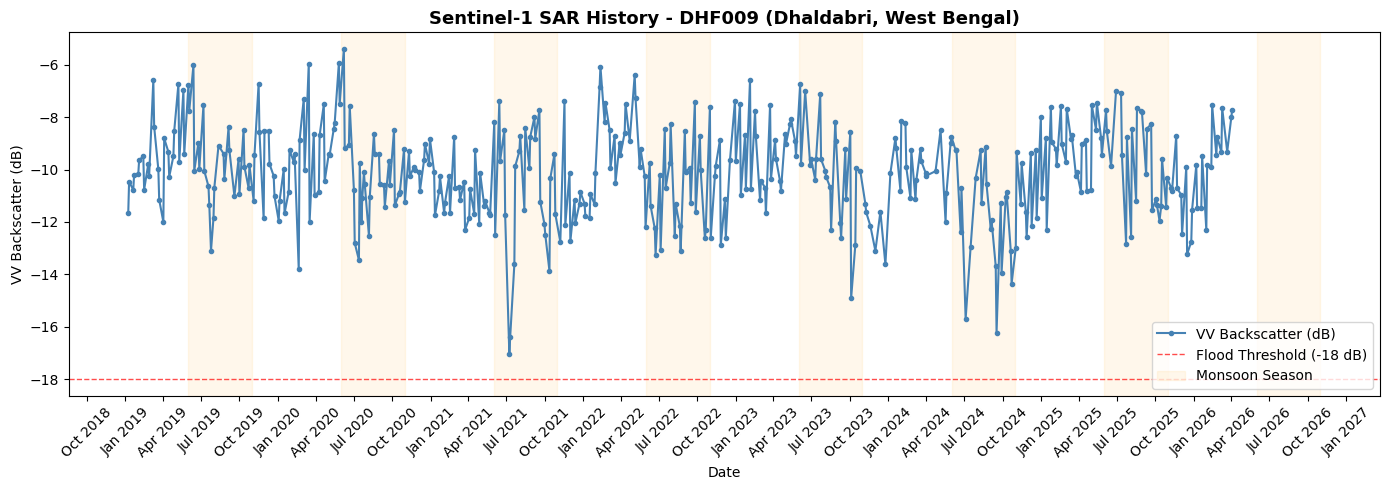

|-- [LOG]: Chart saved to outputs/sar_history_DHF009.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF010 | Farmer_10 | 0.2922 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -15.6 dB to -5.8 dB
 |-- [LOG]: No flood events detected for DHF010


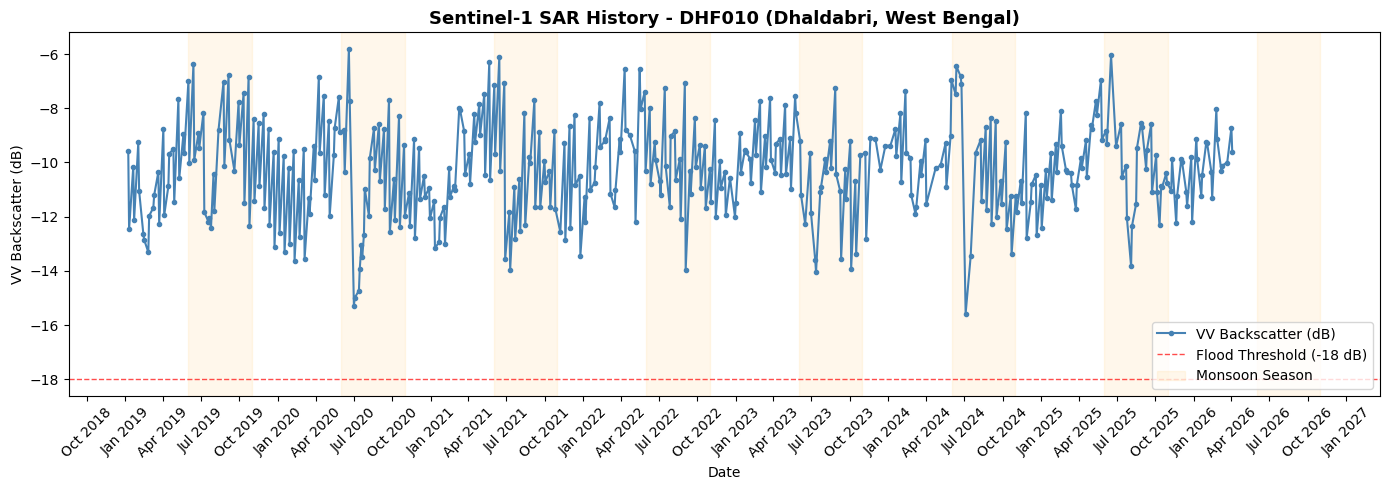

|-- [LOG]: Chart saved to outputs/sar_history_DHF010.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF011 | Farmer_11 | 0.4042 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -14.3 dB to -5.8 dB
 |-- [LOG]: No flood events detected for DHF011


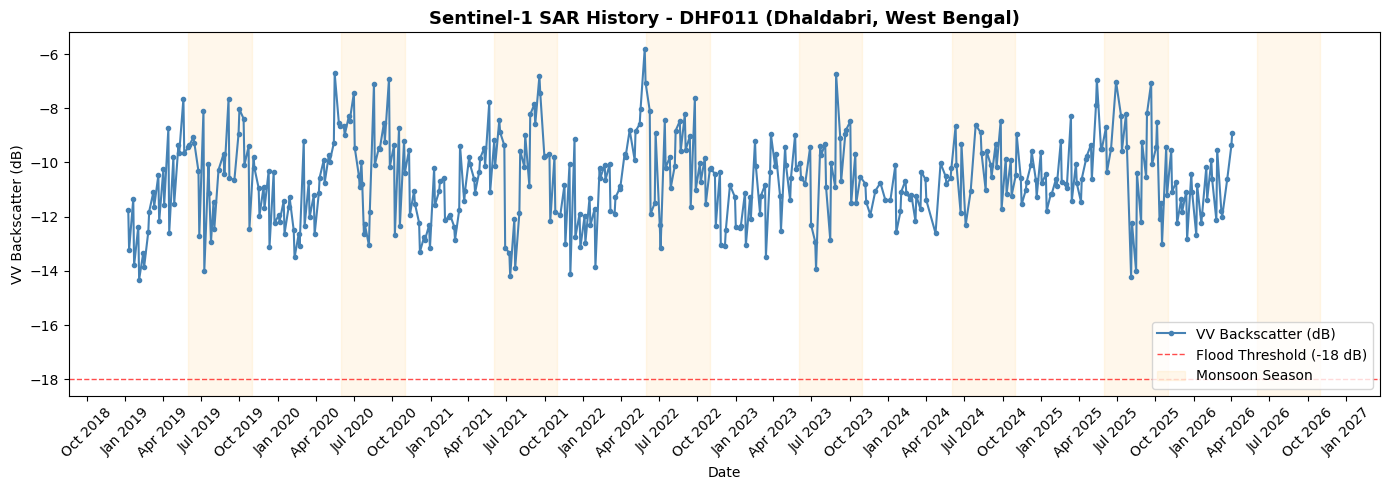

|-- [LOG]: Chart saved to outputs/sar_history_DHF011.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF012 | Farmer_12 | 3.9225 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -15.5 dB to -7.1 dB
 |-- [LOG]: No flood events detected for DHF012


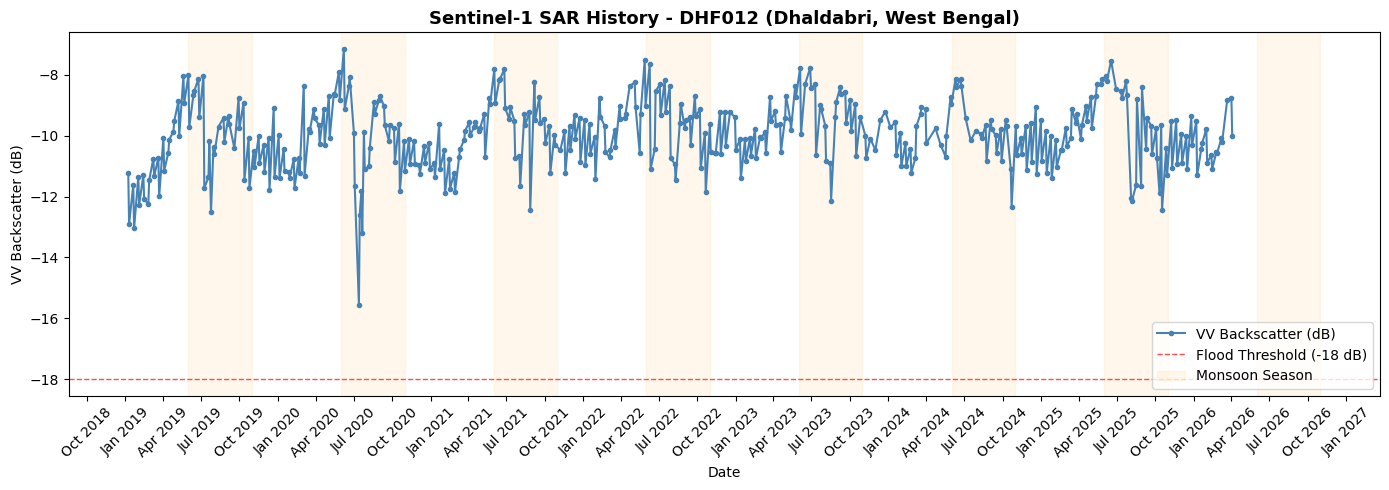

|-- [LOG]: Chart saved to outputs/sar_history_DHF012.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF013 | Farmer_13 | 14.1938 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -17.3 dB to -7.1 dB
 |-- [LOG]: No flood events detected for DHF013


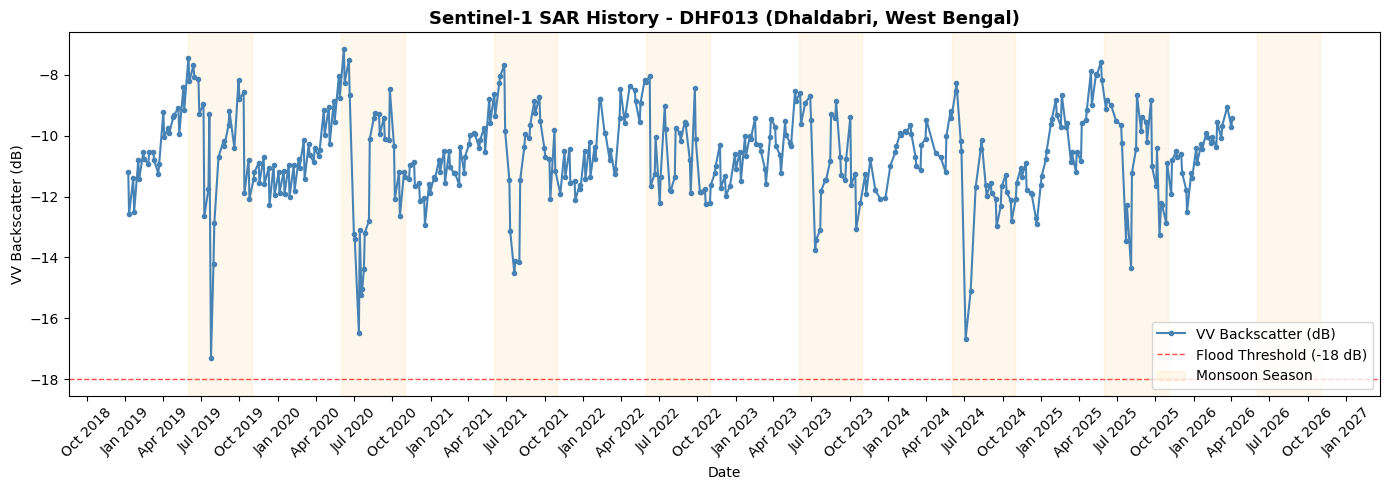

|-- [LOG]: Chart saved to outputs/sar_history_DHF013.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF014 | Farmer_14 | 0.1386 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -14.5 dB to -4.4 dB
 |-- [LOG]: No flood events detected for DHF014


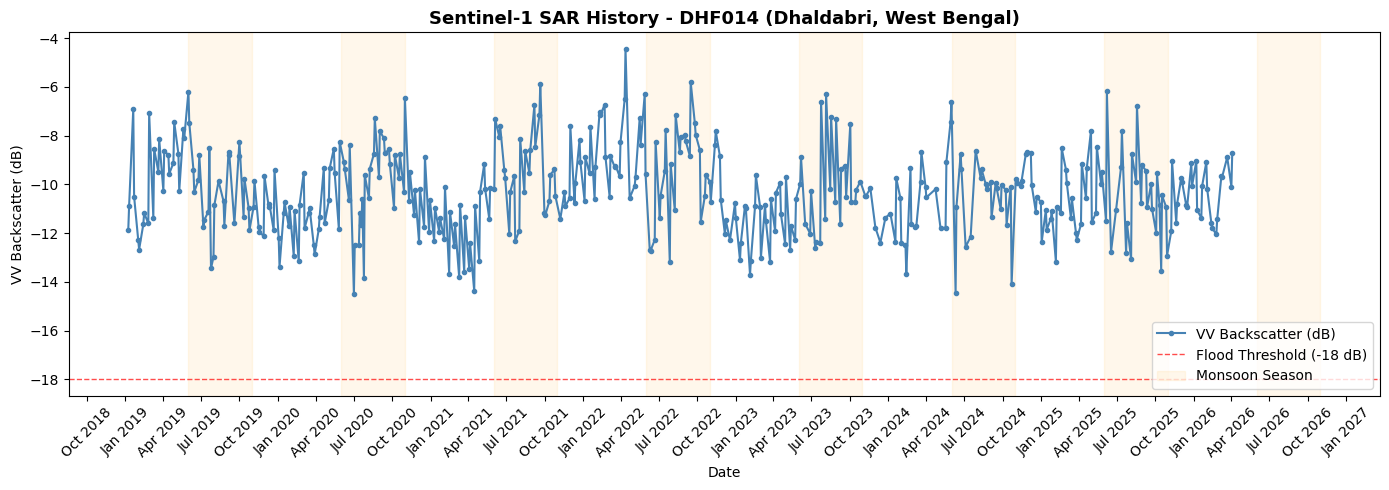

|-- [LOG]: Chart saved to outputs/sar_history_DHF014.png
|-- [WAIT]: Cooling down for 2/3 seconds...

--------------------------------------------------
 |-- [PROCESSING]: DHF016 | Farmer_16 | 0.1588 Ha
|-- [GEE]: Fetching SAR history (2019-2026)...
|-- [LOG]: Retrieved 424 satellite passes
|-- [LOG]: Date range: 2019-01-08 to 2026-04-03
|-- [LOG]: VV range: -15.2 dB to -5.3 dB
 |-- [LOG]: No flood events detected for DHF016


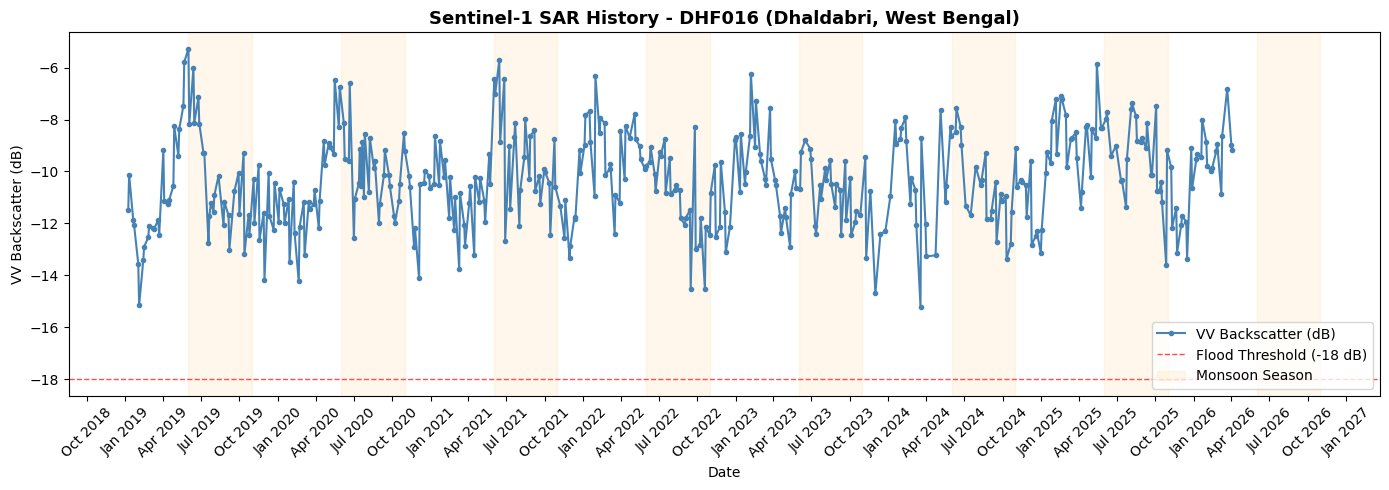

|-- [LOG]: Chart saved to outputs/sar_history_DHF016.png
|-- [WAIT]: Cooling down for 2/3 seconds...

|-- [SUCCESS]: SAR history saved to outputs/sar_backscatter_history.csv
|-- [NEXT]: Day 5 will write flood_status back to PostGIS 


In [20]:
# -- STEP 8: RUN THE ANALYSIS  ----
#==================================================================================== 
def run_day4():
    """
    MASTER FUNCTION:
        - Orchestrates the full Day4 pipeline.

    FLOW:
        - PostGIS (farm shapes) -> GEE (satellite data) -> Flood detection -> Charts ->
         [Day 5: Write results back to PostGIS]
    """
    print("=" * 60)
    print(" DAY 4: THE SATELLITE EYE - CONNECTING EARTH TO SKY")
    print("=" * 60)

    import os
    os.makedirs('outputs', exist_ok=True)

    # Load farms from PostGIS
    farms = load_farms_from_postgis()

    all_results = []

    # Process first 3 farms (GEE has rate limits - be conservative)
    # BACKGROUND:
    #    - GEE's free tier limits how many computations
    #    - We can run per minute. Processing all 12 at once may hit that limit.
    #    - Start with 3, then do the rest.
    
#    for farm in farms[3:]: # Start from the 4th farm
    
    for farm in farms:
        farm_id = farm['farm_id']
        print(f"\n{'-' * 50}")
        print(f" |-- [PROCESSING]: {farm_id} | {farm['farmer_name']} | {farm['area_hectares']} Ha")

        # Convert PostGIS geometry to GEE geometry
        ee_geom = farm_to_ee_geometry(farm['geometry_json'])

        # Fetch SAR time series from GEE
        print(f"|-- [GEE]: Fetching SAR history (2019-2026)...")
        df = fetch_sar_timeseries(farm_id, ee_geom)

        if df.empty:
            continue

        print(f"|-- [LOG]: Retrieved {len(df)} satellite passes")
        print(f"|-- [LOG]: Date range: {df['date'].min().date()} to {df['date'].max().date()}")
        print(f"|-- [LOG]: VV range: {df['vv_db'].min():.1f} dB to {df['vv_db'].max():.1f} dB")


        # Detect flood events
        df, flood_events = detect_flood_events(df)

        if not flood_events.empty:
            print(f"|-- [FLOOD]: {len(flood_events)} potential flood events detected:") 
            for _, row in flood_events.iterrows():
                print(f"    -> {row['date'].strftime('%B %Y')}: {row['vv_db']:.2f} dB ")

        else:
            print(f" |-- [LOG]: No flood events detected for {farm_id}")

        # Plot the time series
        plot_sar_history(farm_id, df, flood_events)

        all_results.append(df)

        # ⏱️ PLACE SLEEP HERE  
        import time
        print(f"|-- [WAIT]: Cooling down for 2/3 seconds...")
        time.sleep(3) 


    # Combine all farm results
    if all_results:
        combined = pd.concat(all_results)
        combined['date'] = combined['date'].dt.strftime('%Y-%m-%d')
        combined.to_csv("outputs/sar_backscatter_history.csv", index=False)
        print(f"\n{'=' * 60}")
        print("|-- [SUCCESS]: SAR history saved to outputs/sar_backscatter_history.csv")
        print("|-- [NEXT]: Day 5 will write flood_status back to PostGIS ")
        print(f"{'=' * 60}")

    return all_results



if __name__ == "__main__":
    results = run_day4()

In [43]:
import pandas as pd
df_audit = pd.read_csv("outputs/sar_backscatter_history.csv")
 
df_audit.groupby('farm_id')['vv_db'].describe()


,count,mean,std,min,25%,50%,75%,max
farm_id,,,,,,,,
DHF005,424.0,-9.940278,1.980233,-15.237829,-11.339546,-9.878002,-8.552343,-4.118593
DHF006,424.0,-10.272499,2.081256,-16.890355,-11.694747,-10.248550,-8.975174,-3.997878
DHF007,424.0,-10.111115,1.783973,-17.049770,-11.272504,-10.045605,-8.874370,-5.393035
DHF008,424.0,-10.269734,1.762433,-15.574293,-11.476445,-10.293906,-9.124576,-5.805396
DHF009,424.0,-10.640934,1.554293,-14.321721,-11.786750,-10.626375,-9.569584,-5.806648
DHF010,424.0,-9.985431,1.115944,-15.549916,-10.721777,-9.932642,-9.276698,-7.145519
DHF011,424.0,-10.639193,1.481669,-17.294114,-11.505088,-10.542725,-9.617853,-7.145166
DHF012,424.0,-10.313081,1.723666,-14.508073,-11.557925,-10.461958,-9.211652,-4.437956
DHF014,424.0,-10.338874,1.772686,-15.201527,-11.687184,-10.431617,-9.051233,-5.279620


In [44]:
# Check the top 5 'wettest' moments across all farms
wettest_moments = df_audit.sort_values('vv_db').head(5)
print("|-- [LOG]: Most saturated soil conditions recorded:")
print(wettest_moments[['farm_id', 'date', 'vv_db']])


|-- [LOG]: Most saturated soil conditions recorded:
     farm_id        date      vv_db
2578  DHF011  2019-07-25 -17.294114
1001  DHF007  2021-07-08 -17.049770
651   DHF006  2022-10-07 -16.890355
2865  DHF011  2024-07-04 -16.665862
2635  DHF011  2020-07-13 -16.485626
